In [100]:
import numpy as np
import cv2 as cv
import matplotlib.pyplot as plt

In [101]:
LPF = np.array([1/np.sqrt(2), 1/np.sqrt(2)]) 
HPF = np.array([1/np.sqrt(2), -(1/np.sqrt(2))])

In [102]:
def convo_h(image, kernel):
    ukuran_kernel = len(kernel)
    padd = np.pad(image, [(0, 0), (0, ukuran_kernel)], mode='constant')
    conv = np.zeros((image.shape[0], image.shape[1]))
    for i in range(len(conv)):
        for j in range(len(conv[i])):
            for x in range(len(kernel)):
                conv[i][j] += (padd[i][j + x] * kernel[x])
    return conv


def convo_v(image, kernel):
    ukuran_kernel = len(kernel)
    padd = np.pad(image, [(0, ukuran_kernel), (0, 0)], mode='constant')
    conv = np.zeros((image.shape[0], image.shape[1]))
    for i in range(len(conv)):
        for j in range(len(conv[i])):
            for x in range(len(kernel)):
                conv[i][j] += (padd[i + x][j] * kernel[x])
    return conv

def downsampling_h(image):
    baris = int(image.shape[0])
    kolom = int(image.shape[1] / 2)
    downsampled = np.zeros((baris, kolom))
    for i in range(baris):
        indeks = 0
        for j in range(kolom):
            downsampled[i][j] = image[i][indeks]
            indeks += 2
    return downsampled

def downsampling_v(image):
    baris = int(image.shape[0] / 2)
    kolom = int(image.shape[1])
    downsampled = np.zeros((baris, kolom))
    indeks = 0
    for i in range(baris):
        for j in range(kolom):
            downsampled[i][j] = image[indeks][j]
        indeks += 2
    return downsampled

def normalisasi(image):
    return (image - np.min(image)) / (np.max(image) - np.min(image)) * 255

def wavelet(image):
    # LL
    k1 = convo_h(image, LPF);
    d1 = downsampling_h(k1)
    k2 = convo_v(d1, LPF);
    d2 = downsampling_v(k2)
    LL_raw = d2;
    LL = normalisasi(d2)

    # LH
    k1 = convo_h(image, LPF);
    d1 = downsampling_h(k1)
    k2 = convo_v(d1, HPF);
    d2 = downsampling_v(k2)
    LH_raw = d2;
    LH = normalisasi(d2)

    # HL
    k1 = convo_h(image, HPF);
    d1 = downsampling_h(k1)
    k2 = convo_v(d1, LPF);
    d2 = downsampling_v(k2)
    HL_raw = d2;
    HL = normalisasi(d2)

    # HH
    k1 = convo_h(image, HPF);
    d1 = downsampling_h(k1)
    k2 = convo_v(d1, HPF);
    d2 = downsampling_v(k2)
    HH_raw = d2;
    HH = normalisasi(d2)

    return LL, LH, HL, HH, LL_raw, LH_raw, HL_raw, HH_raw

In [103]:
def upsampling_v(image):
    baris = image.shape[0] * 2
    kolom = image.shape[1]
    upsampled = np.zeros((baris, kolom))
    for i in range(image.shape[0]):
        for j in range(kolom):
            upsampled[i * 2][j] = image[i][j]
    return upsampled

def upsampling_h(image):
    baris = image.shape[0]
    kolom = image.shape[1] * 2
    upsampled = np.zeros((baris, kolom))
    for i in range(baris):
        for j in range(image.shape[1]):
            upsampled[i][j * 2] = image[i][j]
    return upsampled

def rekonstruksi(LL, LH, HL, HH):
    upsampling = upsampling_v(LL)
    konvolusiL = convo_v(upsampling, LPF)

    upsampling = upsampling_v(LH)
    konvolusiH = convo_v(upsampling, HPF)

    upsampling = upsampling_h(konvolusiL + konvolusiH)
    konvolusiL2 = convo_h(upsampling, LPF)

    upsampling = upsampling_v(HL)
    konvolusiL = convo_v(upsampling, LPF)

    upsampling = upsampling_v(HH)
    konvolusiH = convo_v(upsampling, HPF)

    upsampling = upsampling_h(konvolusiL + konvolusiH)
    konvolusiH2 = convo_h(upsampling, HPF)

    hasil = konvolusiL2 + konvolusiH2
    return hasil

In [104]:
def tresholding(img, batas):
    baris, kolom = img.shape
    canvas = np.zeros_like(img, dtype=np.uint8)
    for i in range(baris):
        for j in range(kolom):
            if(img[i,j] > batas):
                canvas[i,j] = 255
            elif(img[i,j] <= batas):
                canvas[i,j] = 0
    return canvas

In [105]:
kernel5= np.array([
    [0, 0, 1, 0, 0],
    [0, 1, 1, 1, 0],
    [1, 1, 1, 1, 1],
    [0, 1, 1, 1, 0],
    [0, 0, 1, 0, 0]
])

In [106]:
def dilasi(image, kernel):
    height, width = image.shape
    k_height, k_width = kernel.shape
    center = k_height // 2
    hasil = np.zeros((height, width))
    for i in range(center, height - center):
        for j in range(center, width - center):
            if image[i, j] == 255:
                for k in range(k_height):
                    for l in range(k_width):
                        if kernel[k, l] == 1:
                            hasil[i + k - center, j + l - center] = 255
            else:
                if hasil[i, j] != 255:
                    hasil[i, j] = 0
    return hasil

def erosi(image, kernel):
    height, width = image.shape
    k_height, k_width = kernel.shape
    center = k_height // 2
    hasil = np.zeros((height, width))
    for i in range(center, height - center):
        for j in range(center, width - center):
            cocok = True
            for k in range(k_height):
                for l in range(k_width):
                    if kernel[k, l] == 1 and image[i + k - center, j + l - center] == 0:
                        cocok = False
                        break
                if not cocok:
                    break
            if cocok:
                hasil[i, j] = 255
    return hasil

def closing(image, kernel):
    result = erosi(dilasi(image, kernel), kernel)
    return result

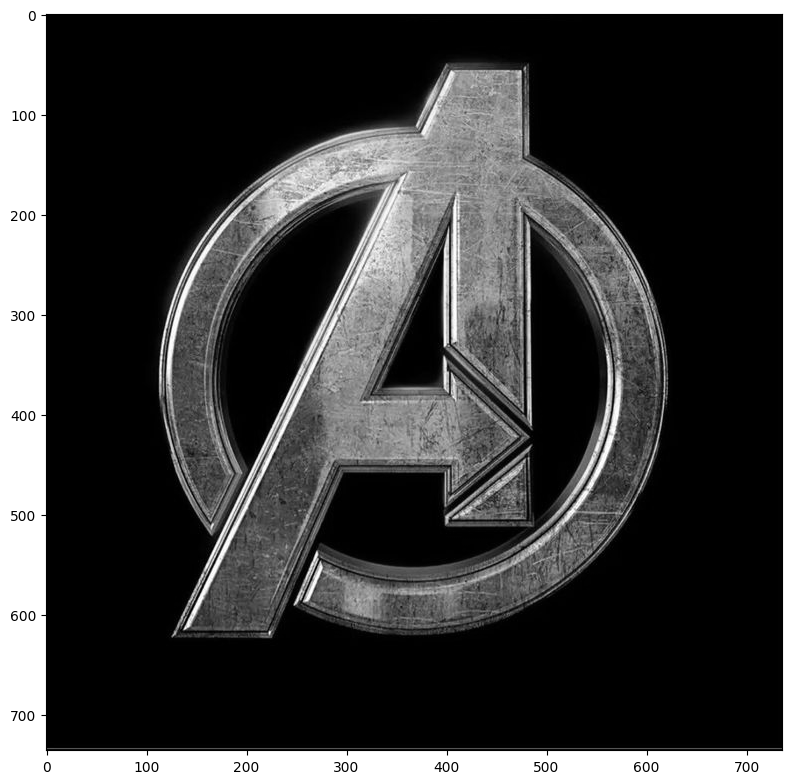

In [107]:
img = cv.imread('doomsday.jpg')
img_gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

plt.figure(figsize=(8, 8))

plt.imshow(img_gray, cmap='gray')

plt.tight_layout()
plt.show()

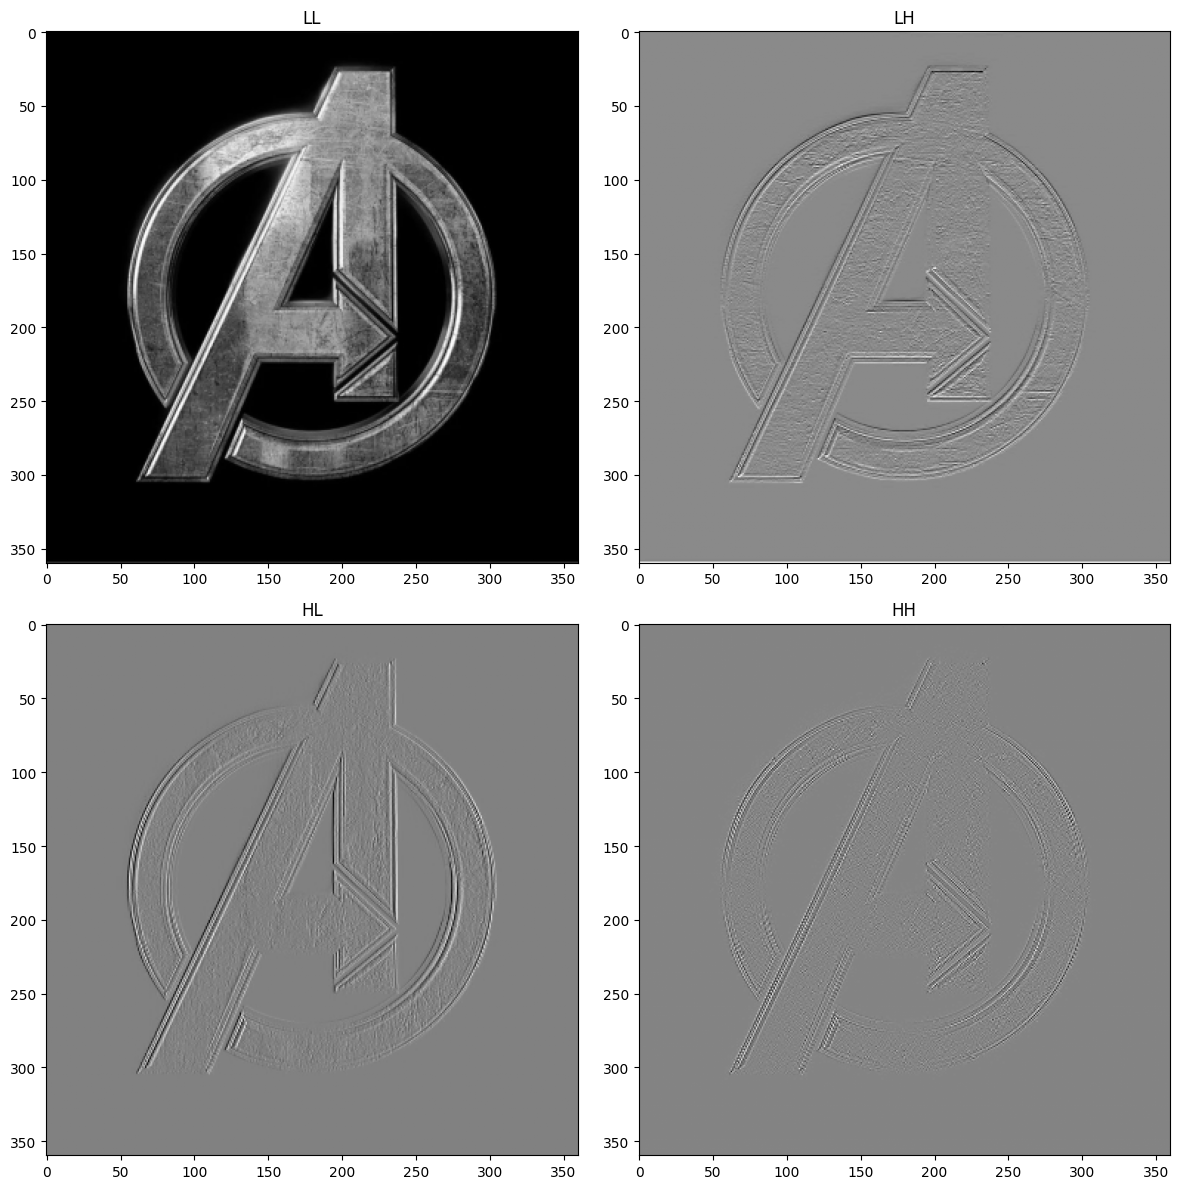

In [108]:
# wavalet transform
img_resize = cv.resize(img_gray, (720,720))
LL, LH, HL, HH, LL_raw, LH_raw, HL_raw, HH_raw = wavelet(img_resize.astype(np.float32))

plt.figure(figsize=(12, 12))
plt.subplot(2, 2, 1)
plt.imshow(LL,  cmap='gray')
plt.title("LL")

plt.subplot(2, 2, 2)
plt.imshow(LH,  cmap='gray')
plt.title("LH")

plt.subplot(2, 2, 3)
plt.imshow(HL, cmap='gray')
plt.title("HL")

plt.subplot(2, 2, 4)
plt.imshow(HH, cmap='gray')
plt.title("HH")

plt.tight_layout()
plt.show()

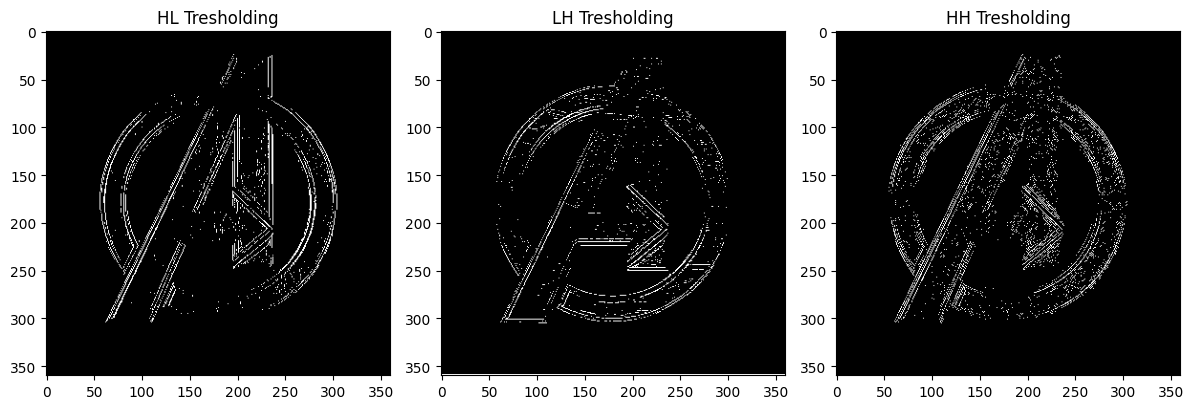

In [109]:
tresholded1 = tresholding(HL, 150)
tresholded2 = tresholding(LH, 165)
tresholded3 = tresholding(HH, 150)

plt.figure(figsize=(12,8))

plt.subplot(1, 3, 1)
plt.imshow(tresholded1, cmap='gray')
plt.title("HL Tresholding")

plt.subplot(1, 3, 2)
plt.imshow(tresholded2, cmap='gray')
plt.title("LH Tresholding")

plt.subplot(1, 3, 3)
plt.imshow(tresholded3, cmap='gray')
plt.title("HH Tresholding")

plt.tight_layout()
plt.show()

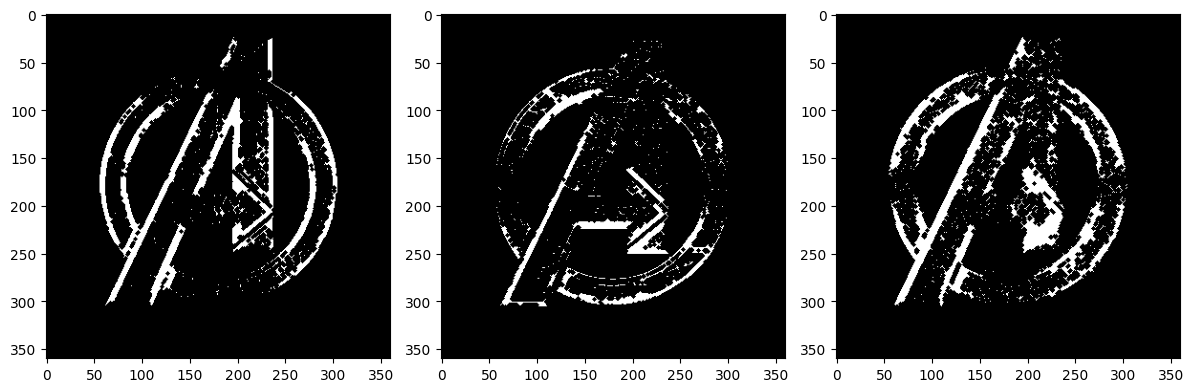

In [110]:
closing1 = closing(tresholded1,kernel5)
closing2 = closing(tresholded2,kernel5)
closing3 = closing(tresholded3,kernel5)

plt.figure(figsize=(12,8))

plt.subplot(1, 3, 1)
plt.imshow(closing1, cmap='gray')

plt.subplot(1, 3, 2)
plt.imshow(closing2, cmap='gray')

plt.subplot(1, 3, 3)
plt.imshow(closing3, cmap='gray')

plt.tight_layout()
plt.show()

Operasi **Morphological Closing** diterapkan pada tiga sub-band hasil thresholding: HL, LH, dan HH. Closing bekerja dengan urutan **Dilasi → Erosi** menggunakan `kernel5` berbentuk diamond 5×5. Tujuan utamanya adalah menghubungkan piksel tepi yang terputus-putus dan menghilangkan noise titik kecil, sehingga struktur tepi menjadi lebih solid dan kontinu.

**a) HL (Horizontal Low, Vertical High) setelah Closing:**
Sub-band HL menangkap perubahan intensitas yang terjadi secara **vertikal** (tepi horizontal). Setelah thresholding dengan batas 150, hasil HL menunjukkan garis-garis tepi vertikal dari logo — seperti sisi kanan dan kiri huruf "A" serta lingkaran luar logo Avengers. Setelah closing, celah-celah kecil antar piksel putih yang tadinya terputus-putus menjadi terhubung. Efeknya, kontur tepi terlihat lebih **solid dan tebal** dibandingkan sebelum closing. Noise titik kecil yang terisolasi sebagian besar ikut tertutup karena tahap dilasi mengisi celah tersebut sebelum erosi menghaluskan batasnya.

**b) LH (Horizontal High, Vertical Low) setelah Closing:**
Sub-band LH menangkap perubahan intensitas yang terjadi secara **horizontal** (tepi vertikal). Thresholding dengan batas 165 (lalu diperbarui ke 150 di cell 12) menghasilkan garis-garis tepi horizontal yang merepresentasikan elemen seperti tepi atas/bawah huruf dan lingkaran logo. Setelah closing, sambungan antar tepi horizontal menjadi lebih **mulus dan menyambung**. Bentuk luar logo dan bagian horizontal huruf "A" terlihat lebih jelas tergambar. Karena kernel tidak terlalu besar, detail halus yang sangat tipis tetap terjaga dan tidak hilang sepenuhnya.

**c) HH (High-High) setelah Closing:**
Sub-band HH menangkap **detail diagonal dan tekstur halus** dari citra — biasanya berupa noise atau tepi-tepi sudut. Karena informasinya merupakan variasi frekuensi tinggi di dua arah sekaligus, hasil thresholding HH menghasilkan pola titik-titik yang tersebar dan tidak beraturan. Setelah closing, titik-titik yang berdekatan mengelompok menjadi bercak-bercak putih yang lebih besar. Karakteristik utamanya: hasil closing HH terlihat paling **"berbercak"** dibandingkan HL dan LH — tidak membentuk garis tepi yang jelas, melainkan kluster-kluster area putih yang mengikuti pola tekstur diagonal logo. Ini menunjukkan bahwa HH lebih sensitif terhadap noise dan detail sudut, bukan struktur tepi dominan satu arah.

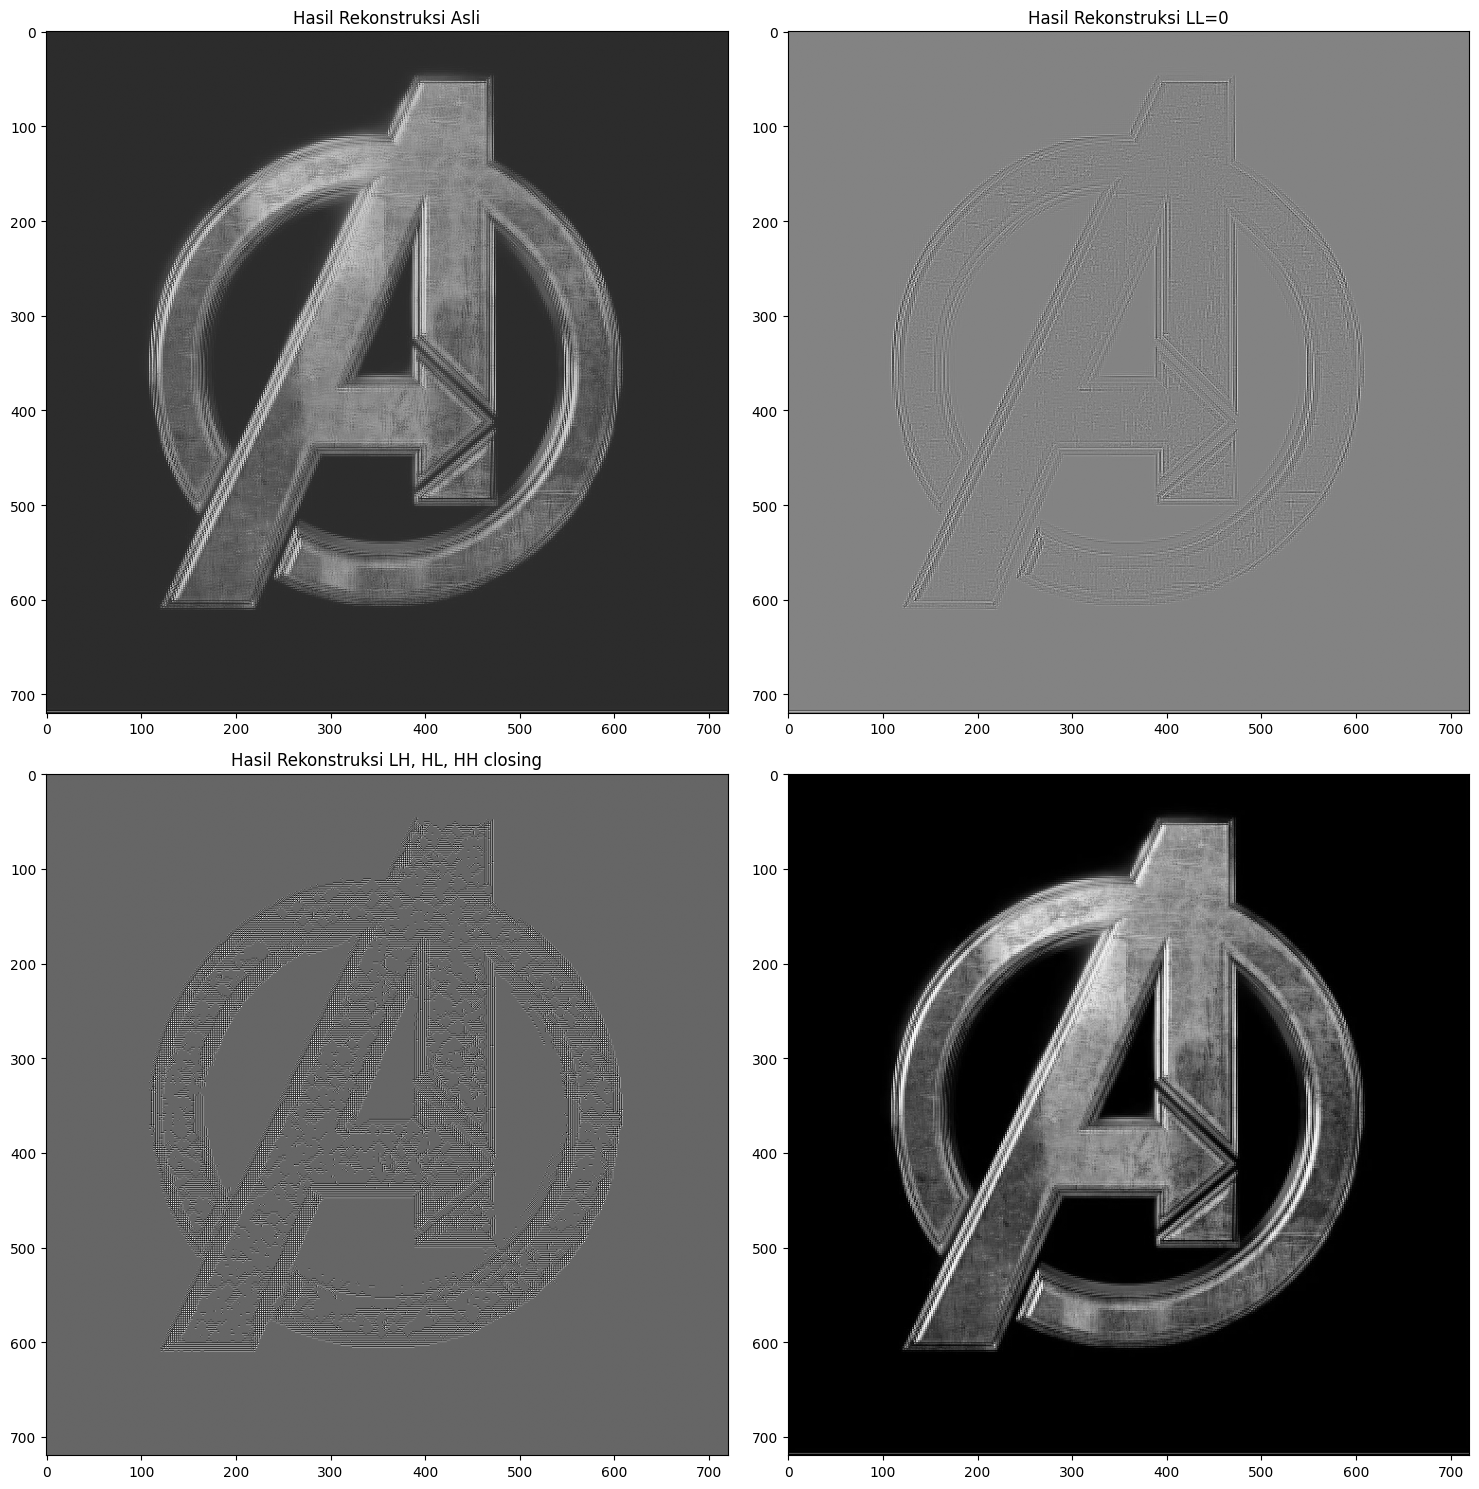

In [111]:
tresholded2 = tresholding(LH, 150)
closing2 = closing(tresholded2,kernel5)

rekon_asli = rekonstruksi(LL, LH_raw, HL_raw, HH_raw)

LL_zeros  = np.zeros_like(LL_raw)
rekon_ll0 = rekonstruksi(LL_zeros, LH_raw, HL_raw, HH_raw)
rekon_closing = rekonstruksi(LL_zeros, closing2, closing1, closing3)
rekon_bonus = rekonstruksi(LL_raw, LH_raw, HL_raw, HH_raw)

rekon_asli_norm = normalisasi(rekon_asli)
rekon_ll0_norm = normalisasi(rekon_ll0)
rekon_closing_norm = normalisasi(rekon_closing)
rekon_bonus_norm = normalisasi(rekon_bonus)

plt.figure(figsize=(15, 15))

plt.subplot(2, 2, 1)
plt.imshow(rekon_asli_norm, cmap='gray')
plt.title('Hasil Rekonstruksi Asli')

plt.subplot(2, 2, 2)
plt.imshow(rekon_ll0_norm, cmap='gray')
plt.title('Hasil Rekonstruksi LL=0')

plt.subplot(2, 2, 3)
plt.imshow(rekon_closing_norm, cmap='gray')
plt.title('Hasil Rekonstruksi LH, HL, HH closing')

plt.subplot(2, 2, 4)
plt.imshow(rekon_bonus_norm, cmap='gray')

plt.tight_layout()
plt.show()


Cell ini melakukan **Inverse Discrete Wavelet Transform (IDWT)** dengan empat variasi berbeda untuk membandingkan kontribusi masing-masing sub-band terhadap gambar akhir.

**a) Rekonstruksi Asli — `rekonstruksi(LL, LH_raw, HL_raw, HH_raw)`:**
Rekonstruksi menggunakan keempat sub-band dalam nilai **float asli** (sebelum dinormalisasi) menghasilkan citra yang hampir identik dengan citra grayscale `img_resize` (720×720). Hal ini sesuai dengan sifat DWT yang **reversibel** — seluruh informasi dari citra asli tersimpan secara terdistribusi pada keempat sub-band, sehingga penggabungan kembali menghasilkan rekonstruksi yang sempurna atau mendekati sempurna. Perlu diperhatikan bahwa `LL` yang digunakan di sini adalah versi **ternormalisasi** (0–255), bukan `LL_raw`, sehingga mungkin ada sedikit perbedaan nilai absolut, namun secara visual hasil rekonstruksi tetap mewakili gambar asli dengan baik.

**b) Rekonstruksi LL = 0 — `rekonstruksi(LL_zeros, LH_raw, HL_raw, HH_raw)`:**
Ketika sub-band LL digantikan dengan **matriks nol**, citra rekonstruksi kehilangan komponen frekuensi rendah yang merupakan pondasi kecerahan dan struktur global citra. Sub-band LL menyimpan informasi aproksimasi (rata-rata intensitas gambar), sehingga tanpa LL hasilnya adalah citra yang **hanya berisi informasi detail/tepi saja**. Hasil rekonstruksi tampak seperti citra abu-abu netral dengan garis-garis tepi halus yang melayang tanpa latar belakang yang jelas. Kontrasnya sangat rendah, warna dominan adalah abu-abu tengah, dan bentuk logo hanya terlihat samar dari detail tepi horizontal, vertikal, dan diagonal. Ini membuktikan bahwa sub-band LL adalah **komponen paling dominan** dalam menentukan tampilan visual keseluruhan gambar.

**c) Rekonstruksi Closing — `rekonstruksi(LL_zeros, closing2, closing1, closing3)`:**
Rekonstruksi ini menggunakan LL=0 dan sub-band detail yang telah melalui **thresholding + closing**, sehingga informasi tepi yang tersisa sudah disederhanakan — hanya tepi-tepi dominan yang bertahan setelah threshold 150, kemudian disambungkan oleh operasi closing. Hasilnya mirip dengan rekonstruksi LL=0 sebelumnya, namun detail tepi yang tampil **lebih tebal, lebih kontinu, dan lebih bersih dari noise halus**. Garis-garis tepi logo terlihat sedikit lebih jelas dan tersambung dibanding rekonstruksi LL=0 dengan sub-band raw. Namun strukturnya tetap "mengambang" karena tidak ada komponen frekuensi rendah dari LL. Analisis ini menegaskan bahwa **closing memperkuat struktur tepi** namun tidak dapat menggantikan peran LL sebagai pembawa informasi warna/kecerahan global.

**d) Rekonstruksi Bonus — `rekonstruksi(LL_raw, LH_raw, HL_raw, HH_raw)`:**
Rekonstruksi keempat menggunakan **semua sub-band dalam nilai raw** (termasuk `LL_raw`). Ini adalah rekonstruksi yang paling lengkap dan menghasilkan citra yang paling mirip dengan gambar asli. Perbedaan dengan rekonstruksi asli (variasi a) adalah pada versi ini `LL_raw` digunakan (bukan `LL` yang sudah ternormalisasi), sehingga informasi aproksimasi frekuensi rendah dipertahankan secara penuh. Hasilnya: citra terlihat mendekati aslinya dengan struktur global yang kuat dan detail tepi yang tajam. Ini membuktikan bahwa **manipulasi sub-band detail saja (tanpa mengubah LL) hanya memberikan perubahan halus pada ketajaman tepi** citra rekonstruksi, sementara karakter visual utama ditentukan oleh LL.

---

### Kesimpulan

Eksperimen ini menunjukkan bahwa **Discrete Wavelet Transform (DWT) menguraikan citra menjadi komponen yang memiliki peran berbeda**:
- Sub-band **LL** memegang kendali atas kecerahan dan struktur global — tanpanya gambar kehilangan identitas visualnya.
- Sub-band **LH dan HL** membawa informasi tepi yang terstruktur (horizontal dan vertikal) yang dapat di-extract dan dibersihkan dengan thresholding + closing.
- Sub-band **HH** mengandung detail diagonal dan noise yang tersebar, kurang cocok untuk deteksi tepi langsung.
- Operasi **Morphological Closing** terbukti efektif untuk menghubungkan tepi yang terputus dan membersihkan noise kecil, menghasilkan edge map yang lebih bersih.
- **IDWT** berhasil merekonstruksi citra mendekati sempurna ketika semua sub-band raw digunakan, sesuai sifat reversibilitas DWT.